In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# --- CHARGEMENT DES LIBRAIRIES ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Chargement du dataset (ton export de la partie R)
df = pd.read_csv("/content/drive/MyDrive/ProjetBigDataIAWeb/BD_arbres_final_complet.csv")

# Suppression de la ligne où 'age_estim' est 2010 (anomalie détectée)
df = df[df['age_estim'] != 2010].copy()

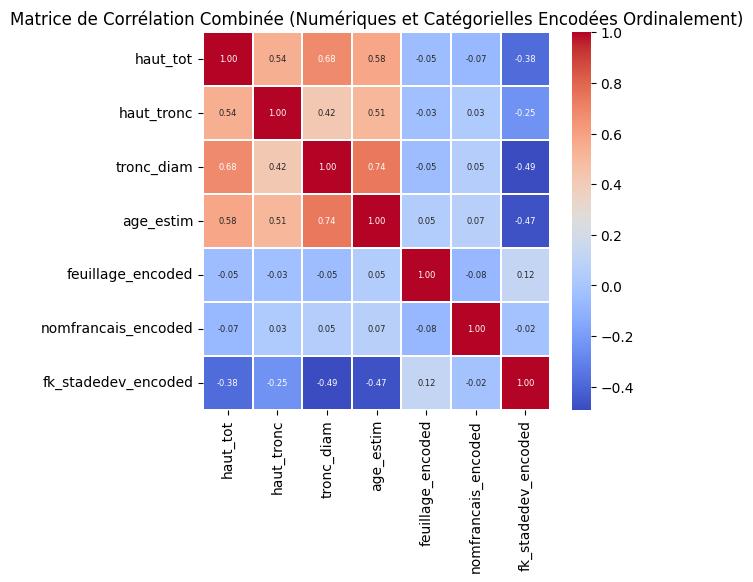

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Colonnes numériques
numerical_cols_user = ['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim']
# Colonnes catégorielles à encoder ordinalement
categorical_cols_to_encode = ['feuillage', 'nomfrancais', 'fk_stadedev']

## Préparation des données pour la corrélation
# 1. Traiter les colonnes numériques
df_numerical_for_corr = df[numerical_cols_user].copy()
for col in numerical_cols_user:
    if df_numerical_for_corr[col].isnull().any():
        df_numerical_for_corr[col] = df_numerical_for_corr[col].fillna(df_numerical_for_corr[col].mean())

# 2. Traiter et encoder les colonnes catégorielles
df_categorical_for_corr = df[categorical_cols_to_encode].copy()
for col in categorical_cols_to_encode:
    if df_categorical_for_corr[col].isnull().any():
        df_categorical_for_corr[col] = df_categorical_for_corr[col].fillna(df_categorical_for_corr[col].mode()[0])

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_categorical_encoded = pd.DataFrame(
    encoder.fit_transform(df_categorical_for_corr),
    columns=[f'{col}_encoded' for col in categorical_cols_to_encode],
    index=df_categorical_for_corr.index # Keep original index
)

# 3. Combiner les données numériques et catégorielles encodées
df_correlation_data = pd.concat([df_numerical_for_corr, df_categorical_encoded], axis=1)

# 5. Calculer la matrice de corrélation pour les colonnes
correlation_matrix_combined = df_correlation_data.corr()

# Visualiser la matrice de corrélation complète avec une heatmap
plt.figure(figsize=(df_correlation_data.shape[1] * 0.8, df_correlation_data.shape[1] * 0.7))
sns.heatmap(correlation_matrix_combined, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.1, annot_kws={"size": 6})
plt.title('Matrice de Corrélation Combinée (Numériques et Catégorielles Encodées Ordinalement)')
plt.show()

In [29]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

results = []

# Initialize df_filtered using df_correlation_data from previous steps
df_filtered = df_correlation_data.copy()

# =========================
# CONFIG
# =========================
feature_sets = {
    #"avec_diam": ['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim'],
    #"sans_diam": ['haut_tot', 'tronc_diam', 'age_estim'],
    "catego" :  ['haut_tot', 'tronc_diam', 'age_estim', 'fk_stadedev_encoded'],
     "cat_tronc" :  ['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim', 'fk_stadedev_encoded']
}

k_values = [2, 3, 4, 5]

# =========================
# LOOP SUR LES CONFIGS
# =========================
for name, features in feature_sets.items():

    df_model = df_filtered[features].dropna()

    # Normalisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_model)

    # =========================
    # 1. SANS PCA
    # =========================
    X_data = X_scaled

    # ----- KMEANS -----
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init
        labels = kmeans.fit_predict(X_data)

        if len(set(labels)) > 1:
            results.append({
                "modele": "KMeans",
                "features": name,
                "PCA": "Non",
                "k": k,
                "silhouette": silhouette_score(X_data, labels),
                "calinski": calinski_harabasz_score(X_data, labels),
                "davies": davies_bouldin_score(X_data, labels)
            })

    # ----- DBSCAN -----
    for eps in [0.3, 0.5, 0.7]:
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(X_data)

        # éviter cas 1 seul cluster ou que du bruit
        if len(set(labels)) > 1 and -1 not in set(labels):
            results.append({
                "modele": "DBSCAN",
                "features": name,
                "PCA": "Non",
                "k": "auto",
                "eps": eps,
                "silhouette": silhouette_score(X_data, labels),
                "calinski": calinski_harabasz_score(X_data, labels),
                "davies": davies_bouldin_score(X_data, labels)
            })

    # ----- Gaussian Mixture Model (GMM) -----
    for n_components in k_values:
        gmm = GaussianMixture(n_components=n_components, random_state=42) # Added random_state
        labels = gmm.fit_predict(X_data)

        if len(set(labels)) > 1: # GMM always assigns to a cluster, so len(set(labels)) will be n_components
            results.append({
                "modele": "GMM",
                "features": name,
                "PCA": "Non",
                "k": n_components,
                "silhouette": silhouette_score(X_data, labels),
                "calinski": calinski_harabasz_score(X_data, labels),
                "davies": davies_bouldin_score(X_data, labels)
            })

    # =========================
    # 2. AVEC PCA
    # =========================
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # ----- KMEANS -----
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init
        labels = kmeans.fit_predict(X_pca)

        if len(set(labels)) > 1:
            results.append({
                "modele": "KMeans",
                "features": name,
                "PCA": "Oui",
                "k": k,
                "silhouette": silhouette_score(X_pca, labels),
                "calinski": calinski_harabasz_score(X_pca, labels),
                "davies": davies_bouldin_score(X_pca, labels)
            })

    # ----- DBSCAN -----
    for eps in [0.3, 0.5, 0.7]:
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(X_pca)

        if len(set(labels)) > 1 and -1 not in set(labels):
            results.append({
                "modele": "DBSCAN",
                "features": name,
                "PCA": "Oui",
                "k": "auto",
                "eps": eps,
                "silhouette": silhouette_score(X_pca, labels),
                "calinski": calinski_harabasz_score(X_pca, labels),
                "davies": davies_bouldin_score(X_pca, labels)
            })

    # ----- Gaussian Mixture Model (GMM) with PCA -----
    for n_components in k_values:
        gmm = GaussianMixture(n_components=n_components, random_state=42) # Added random_state
        labels = gmm.fit_predict(X_pca)

        if len(set(labels)) > 1:
            results.append({
                "modele": "GMM",
                "features": name,
                "PCA": "Oui",
                "k": n_components,
                "silhouette": silhouette_score(X_pca, labels),
                "calinski": calinski_harabasz_score(X_pca, labels),
                "davies": davies_bouldin_score(X_pca, labels)
            })

# =========================
# RESULTATS
# =========================
results_df = pd.DataFrame(results)

# Trier pour voir les meilleurs
results_df = results_df.sort_values(by="silhouette", ascending=False)
results_df = results_df.sort_values(by="k", ascending=False)
print(results_df)

    modele   features  PCA  k  silhouette      calinski    davies
11  KMeans     catego  Oui  5    0.573643  19927.374705  0.563906
15     GMM     catego  Oui  5    0.467783  12738.299967  0.754754
19  KMeans  cat_tronc  Non  5    0.371158   5632.809797  1.219401
23     GMM  cat_tronc  Non  5    0.367260   5362.225136  1.177058
7      GMM     catego  Non  5    0.426037   7675.201310  1.010177
3   KMeans     catego  Non  5    0.428556   8173.482493  0.968528
27  KMeans  cat_tronc  Oui  5    0.457957  14571.524465  0.755925
31     GMM  cat_tronc  Oui  5    0.453975  10932.092871  1.071038
6      GMM     catego  Non  4    0.457982   7547.927509  0.979297
2   KMeans     catego  Non  4    0.444386   8668.517448  0.922631
14     GMM     catego  Oui  4    0.519614  13810.343668  0.800074
10  KMeans     catego  Oui  4    0.586740  17499.405817  0.576073
26  KMeans  cat_tronc  Oui  4    0.510338  15234.597950  0.712243
30     GMM  cat_tronc  Oui  4    0.489313  12215.463816  0.953561
18  KMeans

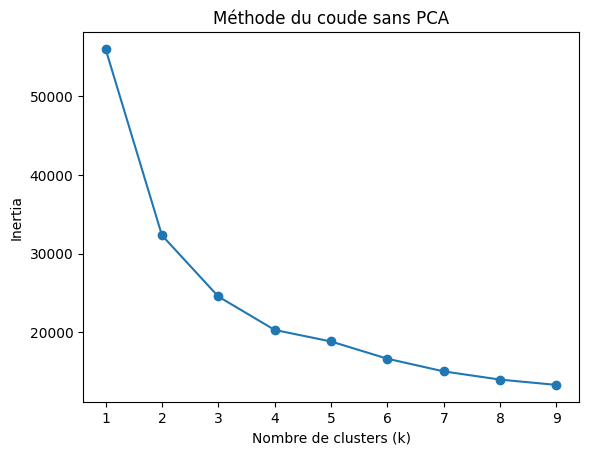

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertia')
plt.title('Méthode du coude sans PCA')
plt.show()

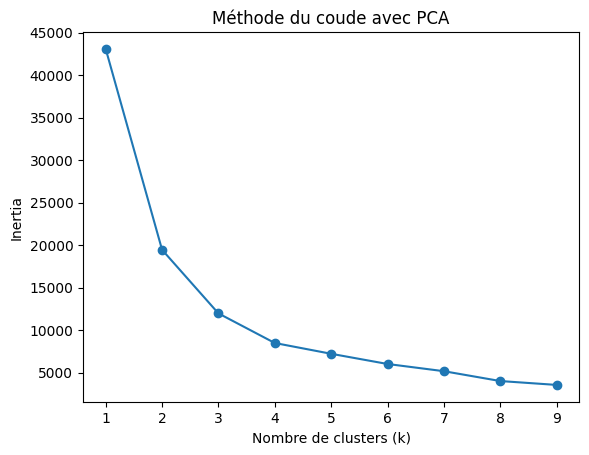

In [31]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertia')
plt.title('Méthode du coude avec PCA')
plt.show()

### Modèle final : K-means k=2 avec PCA

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib #pour sauvegarder les modèles

# Variables finales pour le modèle k=2 (utilisant 'catego' + PCA)
features =  ['haut_tot', 'tronc_diam', 'age_estim', 'fk_stadedev_encoded']
df_model = df_filtered[features].dropna()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(X_pca)

# Renommer les clusters pour k=2
cluster_names_k2 = {0: 'Grand', 1: 'Petit'}
df_model['cluster_name'] = df_model['cluster'].map(cluster_names_k2)

display(df_model.groupby('cluster_name')[['haut_tot', 'tronc_diam',  'age_estim', 'fk_stadedev_encoded']].mean())

# Save the models for k=2 to Google Drive
joblib.dump(kmeans, "/content/drive/MyDrive/ProjetBigDataIAWeb/kmeans_model.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/ProjetBigDataIAWeb/scaler.pkl")
joblib.dump(pca, "/content/drive/MyDrive/ProjetBigDataIAWeb/pca.pkl")

,haut_tot,tronc_diam,age_estim,fk_stadedev_encoded
cluster_name,,,,
Grand,13.836288,134.592805,44.719129,0.036496
Petit,6.735213,55.171014,17.393411,0.865724


['/content/drive/MyDrive/ProjetBigDataIAWeb/pca.pkl']

In [33]:
#Visualisation sur carte

# On récupère les lignes utilisées pour le modèle
df_final = df_filtered.loc[df_model.index].copy()

# Ajout des colonnes Latitude et Longitude du dataframe original 'df'
df_final['Latitude'] = df.loc[df_model.index, 'Latitude']
df_final['Longitude'] = df.loc[df_model.index, 'Longitude']

# On ajoute le cluster et son nom
df_final['cluster'] = df_model['cluster']
df_final['cluster_name'] = df_model['cluster_name']
import plotly.express as px

fig = px.scatter_mapbox(
    df_final,
    lat="Latitude",
    lon="Longitude",
    color="cluster_name",
    color_discrete_map={'Petit': 'blue', 'Grand': 'red'},
    mapbox_style="open-street-map",
    zoom=12,
    title="Répartition des arbres selon leur taille (K-means k=2)"
)

fig.show()


### Modèle K-means avec k=3 et PCA

Nous allons maintenant entraîner et sauvegarder un modèle K-means avec 3 clusters, en utilisant la configuration 'avec_diam' (toutes les caractéristiques numériques) et la PCA, car cela a montré de bons résultats lors de l'évaluation.

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

# Variables finales pour le modèle k=3 (utilisant 'catego' + PCA)
features_k3 = ['haut_tot', 'tronc_diam', 'age_estim', 'fk_stadedev_encoded']
df_model_k3 = df_filtered[features_k3].dropna()

# Scaling
scaler_k3 = StandardScaler()
X_scaled_k3 = scaler_k3.fit_transform(df_model_k3)

# PCA
pca_k3 = PCA(n_components=2)
X_pca_k3 = pca_k3.fit_transform(X_scaled_k3)

# KMeans avec k=3
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model_k3['cluster_k3'] = kmeans_k3.fit_predict(X_pca_k3)

# Renommer les clusters pour k=3
cluster_names_k3 = {0: 'Petit', 1: 'Grand', 2: 'Moyen'}
df_model_k3['cluster_name_k3'] = df_model_k3['cluster_k3'].map(cluster_names_k3)

print("Moyennes des caractéristiques par cluster (k=3):")
display(df_model_k3.groupby('cluster_name_k3')[features_k3].mean())

# Sauvegarder les modèles k=3 sur Google Drive
joblib.dump(kmeans_k3, "/content/drive/MyDrive/ProjetBigDataIAWeb/kmeans_model_k3.pkl")
joblib.dump(scaler_k3, "/content/drive/MyDrive/ProjetBigDataIAWeb/scaler_k3.pkl")
joblib.dump(pca_k3, "/content/drive/MyDrive/ProjetBigDataIAWeb/pca_k3.pkl")

Moyennes des caractéristiques par cluster (k=3):


,haut_tot,tronc_diam,age_estim,fk_stadedev_encoded
cluster_name_k3,,,,
Grand,18.921569,173.454628,54.426099,0.124487
Moyen,10.045964,103.472902,35.717853,0.001143
Petit,6.661161,52.229059,16.505395,1.002807


['/content/drive/MyDrive/ProjetBigDataIAWeb/pca_k3.pkl']

In [35]:
# Visualisation sur carte pour le modèle k=3

# On récupère les lignes utilisées pour le modèle k=3
df_final_k3 = df_filtered.loc[df_model_k3.index].copy()

# Ajout des colonnes Latitude et Longitude du dataframe original 'df'
df_final_k3['Latitude'] = df.loc[df_model_k3.index, 'Latitude']
df_final_k3['Longitude'] = df.loc[df_model_k3.index, 'Longitude']

# On ajoute le cluster et son nom
df_final_k3['cluster_k3'] = df_model_k3['cluster_k3']
df_final_k3['cluster_name_k3'] = df_model_k3['cluster_name_k3']

print("Répartition des points par cluster_k3:")
print(df_final_k3['cluster_name_k3'].value_counts())

import plotly.express as px

fig_k3 = px.scatter_mapbox(
    df_final_k3,
    lat="Latitude",
    lon="Longitude",
    color="cluster_name_k3",
    color_discrete_sequence=px.colors.qualitative.Plotly,
    mapbox_style="open-street-map",
    zoom=12,
    title="Répartition des arbres selon leur taille (modèle K-means k=3)"
)

fig_k3.show()

Répartition des points par cluster_k3:
cluster_name_k3
Petit    4632
Moyen    4373
Grand    2193
Name: count, dtype: int64


### Script de prédiction de cluster d'arbre


In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Definitions et Modèles pour k=2 ---
# Charger les modèles sauvegardés
try:
    kmeans_loaded = joblib.load('kmeans_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    pca_loaded = joblib.load('pca.pkl')
except FileNotFoundError:
    print("Erreur: Un ou plusieurs fichiers de modèle k=2 n'ont pas été trouvés. Assurez-vous d'exécuter les cellules précédentes pour sauvegarder les modèles.")
    kmeans_loaded = None
    scaler_loaded = None
    pca_loaded = None

def predict_tree_cluster(haut_tot, tronc_diam, age_estim, fk_stadedev_encoded):
    """
    Prédit le cluster d'un arbre donné ses spécificités, en utilisant le modèle k=2 avec PCA.

    Args:
        haut_tot (float): Hauteur totale de l'arbre.
        tronc_diam (float): Diamètre du tronc de l'arbre.
        age_estim (float): Âge estimé de l'arbre.
        fk_stadedev_encoded (float): Stade de développement encodé de l'arbre.

    Returns:
        int: Le cluster prédit pour l'arbre (0 ou 1).
             Retourne -1 si les modèles n'ont pas été chargés.
    """
    if kmeans_loaded is None or scaler_loaded is None or pca_loaded is None:
        return -1

    # Créer un tableau numpy avec les caractéristiques d'entrée
    tree_features_np = np.array([[haut_tot, tronc_diam, age_estim, fk_stadedev_encoded]])

    # Noms des caractéristiques utilisées pour l'entraînement
    features_names = ['haut_tot', 'tronc_diam', 'age_estim', 'fk_stadedev_encoded']

    # Convertir en DataFrame pour conserver les noms de colonnes
    tree_features_df = pd.DataFrame(tree_features_np, columns=features_names)

    # Appliquer le scaler et la PCA
    scaled_features = scaler_loaded.transform(tree_features_df)
    pca_features = pca_loaded.transform(scaled_features)
    cluster = kmeans_loaded.predict(pca_features)[0]

    return int(cluster)

# --- Definitions et Modèles pour k=3 ---
# Charger les modèles sauvegardés pour k=3
try:
    kmeans_loaded_k3 = joblib.load('kmeans_model_k3.pkl')
    scaler_loaded_k3 = joblib.load('scaler_k3.pkl')
    pca_loaded_k3 = joblib.load('pca_k3.pkl')
except FileNotFoundError:
    print("Erreur: Un ou plusieurs fichiers de modèle k=3 n'ont pas été trouvés. Assurez-vous d'exécuter les cellules précédentes pour sauvegarder les modèles k=3.")
    kmeans_loaded_k3 = None
    scaler_loaded_k3 = None
    pca_loaded_k3 = None

def predict_tree_cluster_k3(haut_tot, tronc_diam, age_estim, fk_stadedev_encoded):
    """
    Prédit le cluster d'un arbre donné ses spécificités, en utilisant le modèle k=3 avec PCA.

    Args:
        haut_tot (float): Hauteur totale de l'arbre.
        tronc_diam (float): Diamètre du tronc de l'arbre.
        age_estim (float): Âge estimé de l'arbre.
        fk_stadedev_encoded (float): Stade de développement encodé de l'arbre.

    Returns:
        int: Le cluster prédit pour l'arbre (0, 1 ou 2).
             Retourne -1 si les modèles n'ont pas été chargés.
    """
    if kmeans_loaded_k3 is None or scaler_loaded_k3 is None or pca_loaded_k3 is None:
        return -1

    # Créer un tableau numpy avec les caractéristiques d'entrée
    tree_features_np = np.array([[haut_tot, tronc_diam, age_estim, fk_stadedev_encoded]])

    # Noms des caractéristiques utilisées pour l'entraînement du scaler k=3 (doit correspondre à 'catego')
    features_names_k3 = ['haut_tot', 'tronc_diam', 'age_estim', 'fk_stadedev_encoded']

    # Convertir en DataFrame pour conserver les noms de colonnes
    tree_features_df = pd.DataFrame(tree_features_np, columns=features_names_k3)

    # Appliquer le scaler et la PCA
    scaled_features = scaler_loaded_k3.transform(tree_features_df)
    pca_features = pca_loaded_k3.transform(scaled_features)
    cluster = kmeans_loaded_k3.predict(pca_features)[0]

    return int(cluster)

# --- Dynamic Prediction Function ---
def predict_tree_cluster_dynamic(num_clusters, haut_tot, tronc_diam, age_estim, fk_stadedev_encoded):
    """
    Prédit le cluster d'un arbre en choisissant dynamiquement entre les modèles k=2 et k=3.

    Args:
        num_clusters (int): Le nombre de clusters à utiliser (2 ou 3).
        haut_tot (float): Hauteur totale de l'arbre.
        tronc_diam (float): Diamètre du tronc de l'arbre.
        age_estim (float): Âge estimé de l'arbre.
        fk_stadedev_encoded (float): Stade de développement encodé de l'arbre.

    Returns:
        int: Le cluster prédit pour l'arbre.
             Retourne -1 si les modèles n'ont pas été chargés ou si num_clusters n'est pas 2 ou 3.
    """
    if num_clusters == 2:
        return predict_tree_cluster(haut_tot, tronc_diam, age_estim, fk_stadedev_encoded)
    elif num_clusters == 3:
        return predict_tree_cluster_k3(haut_tot, tronc_diam, age_estim, fk_stadedev_encoded)
    else:
        print("Erreur: num_clusters doit être 2 ou 3.")
        return -1


# Utilisation du modèle k=2
example_tree_small = {"haut_tot": 5, "tronc_diam": 40, "age_estim": 10, "fk_stadedev_encoded": 1.0} # Exemple avec 'Jeune' encodé à 1.0
cluster_dynamic_small_k2 = predict_tree_cluster_dynamic(2, **example_tree_small)
print(f"Arbre 1 (petit, k=2): {example_tree_small} -> Cluster: {cluster_dynamic_small_k2}")

example_tree_large = {"haut_tot": 15, "tronc_diam": 130, "age_estim": 45, "fk_stadedev_encoded": 0.0} # Exemple avec 'Adulte' encodé à 0.0
cluster_dynamic_large_k2 = predict_tree_cluster_dynamic(2, **example_tree_large)
print(f"Arbre 2 (grand, k=2): {example_tree_large} -> Cluster: {cluster_dynamic_large_k2}")

# Utilisation du modèle k=3
example_tree_k3_1 = {"haut_tot": 5, "tronc_diam": 40, "age_estim": 10, "fk_stadedev_encoded": 1.0}
cluster_dynamic_k3_1 = predict_tree_cluster_dynamic(3, **example_tree_k3_1)
print(f"Arbre 1 (k=3): {example_tree_k3_1} -> Cluster: {cluster_dynamic_k3_1}")

example_tree_k3_2 = {"haut_tot": 15, "tronc_diam": 130, "age_estim": 45, "fk_stadedev_encoded": 0.0}
cluster_dynamic_k3_2 = predict_tree_cluster_dynamic(3, **example_tree_k3_2)
print(f"Arbre 2 (k=3): {example_tree_k3_2} -> Cluster: {cluster_dynamic_k3_2}")

example_tree_k3_3 = {"haut_tot": 25, "tronc_diam": 200, "age_estim": 70, "fk_stadedev_encoded": 0.0}
cluster_dynamic_k3_3 = predict_tree_cluster_dynamic(3, **example_tree_k3_3)
print(f"Arbre 3 (k=3): {example_tree_k3_3} -> Cluster: {cluster_dynamic_k3_3}")



# PARTIE Demande à l'utilisateur
print("Veuillez entrer les informations de l'arbre pour la prédiction de cluster.")

# Demander à l'utilisateur d'entrer les valeurs
try:
    input_haut_tot = float(input("Entrez la hauteur totale de l'arbre en m (float): "))
    input_tronc_diam = float(input("Entrez le diamètre du tronc de l'arbre en cm (float): "))
    input_age_estim = float(input("Entrez l'âge estimé de l'arbre (float): "))

    # Pour 'fk_stadedev_encoded', l'utilisateur doit connaître l'encodage
    # Par exemple: 'Adulte': 0.0, 'Jeune': 1.0, 'Mature': 2.0, 'Semis': 3.0, 'Vieux': 4.0
    input_fk_stadedev_encoded = float(input("Entrez le stade de développement encodé de l'arbre (0.0 pour Adulte, 1.0 pour Jeune, etc.): "))

    input_num_clusters = int(input("Entrez le nombre de clusters à utiliser (2 ou 3): "))

    # Appeler la fonction de prédiction dynamique
    predicted_cluster = predict_tree_cluster_dynamic(
        num_clusters=input_num_clusters,
        haut_tot=input_haut_tot,
        tronc_diam=input_tronc_diam,
        age_estim=input_age_estim,
        fk_stadedev_encoded=input_fk_stadedev_encoded
    )

    if predicted_cluster != -1:
        print(f"Le cluster prédit pour l'arbre avec {input_num_clusters} clusters est : {predicted_cluster}")

        if input_num_clusters == 2:
            cluster_names_k2_map = {0: 'Grand', 1: 'Petit'}
            cluster_name = cluster_names_k2_map.get(predicted_cluster, 'Inconnu')
            print(f"Nom du cluster (k=2): {cluster_name}")
        elif input_num_clusters == 3:
            cluster_names_k3_map = {0: 'Petit', 1: 'Grand', 2: 'Moyen'}
            cluster_name = cluster_names_k3_map.get(predicted_cluster, 'Inconnu')
            print(f"Nom du cluster (k=3): {cluster_name}")


except ValueError:
    print("Erreur: Veuillez entrer des valeurs numériques valides pour toutes les caractéristiques.")
except Exception as e:
    print(f"Une erreur inattendue est survenue: {e}")

Arbre 1 (petit, k=2): {'haut_tot': 5, 'tronc_diam': 40, 'age_estim': 10, 'fk_stadedev_encoded': 1.0} -> Cluster: 1
Arbre 2 (grand, k=2): {'haut_tot': 15, 'tronc_diam': 130, 'age_estim': 45, 'fk_stadedev_encoded': 0.0} -> Cluster: 0
Arbre 1 (k=3): {'haut_tot': 5, 'tronc_diam': 40, 'age_estim': 10, 'fk_stadedev_encoded': 1.0} -> Cluster: 0
Arbre 2 (k=3): {'haut_tot': 15, 'tronc_diam': 130, 'age_estim': 45, 'fk_stadedev_encoded': 0.0} -> Cluster: 2
Arbre 3 (k=3): {'haut_tot': 25, 'tronc_diam': 200, 'age_estim': 70, 'fk_stadedev_encoded': 0.0} -> Cluster: 1
Veuillez entrer les informations de l'arbre pour la prédiction de cluster.
